In [277]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
INPUT_PATH = "name_img.png"

GRID_SIZE = 120

NOISE_LEVELS = [
    0.40,
    0.45
]

RANDOM_SEED = None

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [279]:
def load_pixel_art(image_path, grid_size=120, threshold=128):
    img = Image.open(image_path).convert("RGBA")

    if img.size != (grid_size, grid_size):
        raise ValueError(
            f"L'immagine deve essere esattamente {grid_size}x{grid_size} pixel. "
            f"L'immagine caricata è {img.size[0]}x{img.size[1]}."
        )

    rgba = np.array(img)

    rgb = rgba[:, :, :3].astype(np.float32)
    alpha = rgba[:, :, 3].astype(np.float32) / 255.0

    white_background = np.full_like(rgb, 255)

    rgb = (
        rgb * alpha[:, :, None]
        + white_background * (1 - alpha[:, :, None])
    )

    gray = (
        0.299 * rgb[:, :, 0]
        + 0.587 * rgb[:, :, 1]
        + 0.114 * rgb[:, :, 2]
    )

    subject = (gray < threshold).astype(np.uint8)

    return subject

In [280]:
def find_available_background(subject):
    return (subject == 0).astype(np.uint8)

In [281]:
def split_subject(subject, rng):
    subject_positions = np.argwhere(subject == 1)

    shuffled_positions = subject_positions.copy()
    rng.shuffle(shuffled_positions)

    split_index = len(shuffled_positions) // 2

    s1_base = np.zeros_like(subject)
    s2_base = np.zeros_like(subject)

    for y, x in shuffled_positions[:split_index]:
        s1_base[y, x] = 1

    for y, x in shuffled_positions[split_index:]:
        s2_base[y, x] = 1

    return s1_base, s2_base

In [282]:
def prepare_noise_positions(external_background, rng):
    positions = np.argwhere(external_background == 1)

    shuffled_positions = positions.copy()
    rng.shuffle(shuffled_positions)

    return shuffled_positions

In [283]:
def create_noise(shape, noise_positions, density):
    noise = np.zeros(shape, dtype=np.uint8)

    number_of_noise_pixels = int(
        len(noise_positions) * density
    )

    selected_positions = noise_positions[:number_of_noise_pixels]

    for y, x in selected_positions:
        noise[y, x] = 1

    return noise

In [284]:
def add_noise_to_shares(s1_base, s2_base, noise):
    s1 = np.maximum(s1_base, noise)
    s2 = np.maximum(s2_base, noise)

    reconstructed = np.maximum(s1, s2)

    return s1, s2, reconstructed

In [285]:
def show_pixel_art(array, title):
    plt.figure(figsize=(6, 6))

    plt.imshow(
        array,
        cmap="gray_r",
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

In [286]:
def save_pixel_art(array, output_path, export_size=1254):
    image_array = np.where(
        array == 1,
        0,
        255
    ).astype(np.uint8)

    image = Image.fromarray(image_array, mode="L")

    image = image.resize(
        (export_size, export_size),
        Image.Resampling.NEAREST
    )

    image.save(output_path)

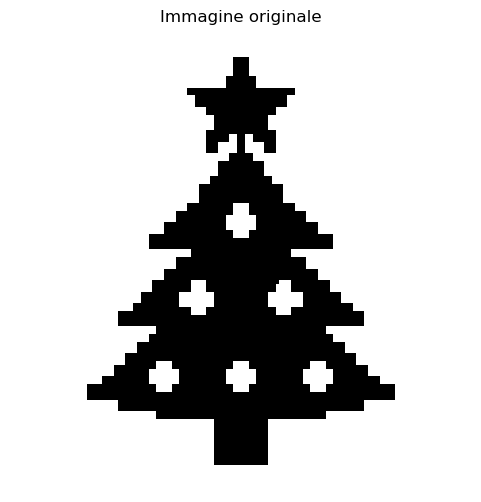

In [287]:
subject = load_pixel_art(
    INPUT_PATH,
    grid_size=GRID_SIZE
)

rng = np.random.default_rng(RANDOM_SEED)

available_background = find_available_background(subject)

s1_base, s2_base = split_subject(
    subject,
    rng
)

noise_positions = prepare_noise_positions(
    available_background,
    rng
)

show_pixel_art(
    subject,
    "Immagine originale"
)

In [288]:
base_reconstruction = np.maximum(
    s1_base,
    s2_base
)

assert np.array_equal(
    base_reconstruction,
    subject
), "ERRORE: S1 e S2 non ricostruiscono correttamente la figura."

assert not np.any(
    (s1_base == 1) & (s2_base == 1)
), "ERRORE: alcuni pixel della figura sono presenti sia in S1 che in S2."

print("Divisione S1/S2 corretta.")
print("Pixel della figura:", np.sum(subject))
print("Pixel assegnati a S1:", np.sum(s1_base))
print("Pixel assegnati a S2:", np.sum(s2_base))

Divisione S1/S2 corretta.
Pixel della figura: 3273
Pixel assegnati a S1: 1636
Pixel assegnati a S2: 1637


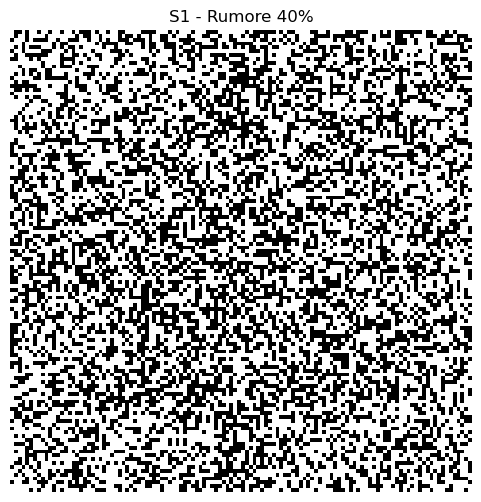

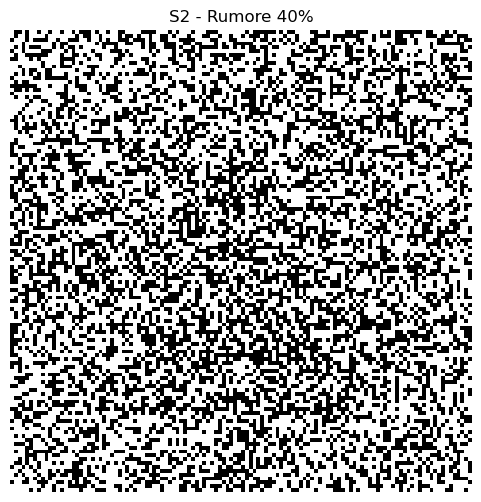

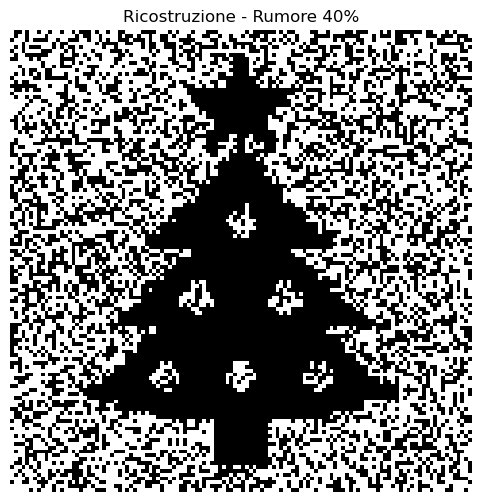

Rumore 40% completato (4450 pixel di rumore).


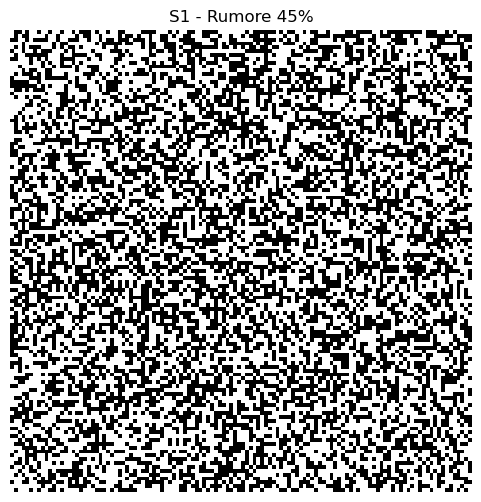

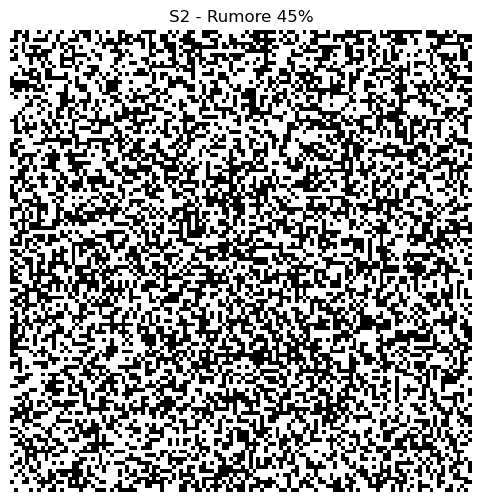

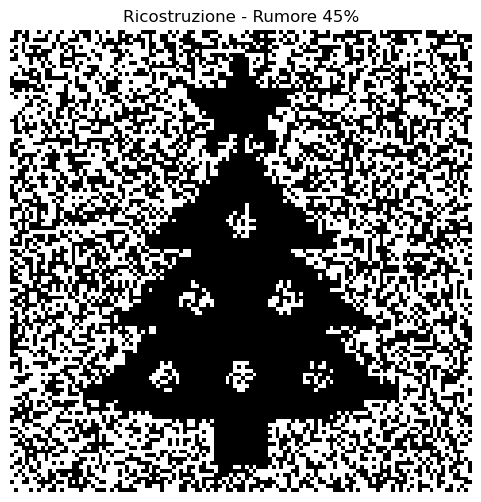

Rumore 45% completato (5007 pixel di rumore).


In [289]:
for noise_density in NOISE_LEVELS:

    percentage = int(noise_density * 100)

    noise = create_noise(
        subject.shape,
        noise_positions,
        noise_density
    )

    s1, s2, reconstructed = add_noise_to_shares(
        s1_base,
        s2_base,
        noise
    )

    expected_reconstruction = np.maximum(
        subject,
        noise
    )

    assert np.array_equal(
        reconstructed,
        expected_reconstruction
    ), f"Errore nella ricostruzione con rumore {percentage}%."

    show_pixel_art(
        s1,
        f"S1 - Rumore {percentage}%"
    )

    show_pixel_art(
        s2,
        f"S2 - Rumore {percentage}%"
    )

    show_pixel_art(
        reconstructed,
        f"Ricostruzione - Rumore {percentage}%"
    )

    save_pixel_art(
        s1,
        OUTPUT_DIR / f"S1_{percentage:02d}.png"
    )

    save_pixel_art(
        s2,
        OUTPUT_DIR / f"S2_{percentage:02d}.png"
    )

    save_pixel_art(
        reconstructed,
        OUTPUT_DIR / f"ricostruzione_{percentage:02d}.png"
    )

    print(
        f"Rumore {percentage}% completato "
        f"({np.sum(noise)} pixel di rumore)."
    )

In [290]:
print("\nFile generati:\n")

for noise_density in NOISE_LEVELS:
    percentage = int(noise_density * 100)

    print(
        f"{percentage}% -> "
        f"S1_{percentage:02d}.png, "
        f"S2_{percentage:02d}.png, "
        f"ricostruzione_{percentage:02d}.png"
    )


File generati:

40% -> S1_40.png, S2_40.png, ricostruzione_40.png
45% -> S1_45.png, S2_45.png, ricostruzione_45.png
